In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [36]:
# Loading the data
rng = np.random.default_rng(42)
n = 500
df = pd.DataFrame({
    "lectures_watched":      rng.integers(0, 41, n),
    "assignments_completed": rng.integers(0, 11, n),
    "quiz_score":            rng.integers(30, 101, n),
    "weekly_study_hours":    np.round(rng.uniform(0, 20, n), 1),
})
z = (0.10 * df.lectures_watched + 0.45 * df.assignments_completed
     + 0.03 * df.quiz_score + 0.12 * df.weekly_study_hours - 8.5
     + rng.normal(0, 1.0, n))
df["completed"] = (1 / (1 + np.exp(-z)) > rng.uniform(0, 1, n)).astype(int)
df.head()

,lectures_watched,assignments_completed,quiz_score,weekly_study_hours,completed
0,3,1,87,5.2,0
1,31,7,82,6.4,0
2,26,10,69,4.8,0
3,17,9,92,9.6,0
4,17,3,39,13.7,0


In [37]:
features = ["lectures_watched", "assignments_completed", "quiz_score", "weekly_study_hours"]
X = df[features]
y = df["completed"]
y.value_counts().rename({1: "Complete", 0: "Not Complete"})

completed
Not Complete    318
Complete        182
Name: count, dtype: int64

In [38]:
# Train/ test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (400, 4) Test: (100, 4)


In [39]:
# train Logistic Regression
model = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)

In [40]:
# Predictions on the test set
y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]

In [41]:
# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Accuracy: 0.790


,Pred Not Complete,Pred Complete
Actual Not Complete,55,9
Actual Complete,12,24


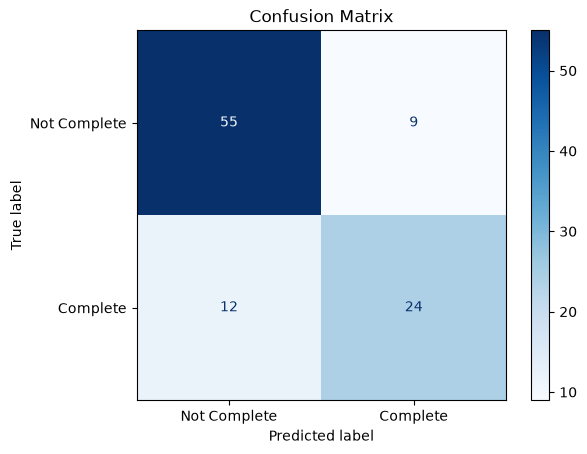

              precision    recall  f1-score   support

Not Complete       0.82      0.86      0.84        64
    Complete       0.73      0.67      0.70        36

    accuracy                           0.79       100
   macro avg       0.77      0.76      0.77       100
weighted avg       0.79      0.79      0.79       100



In [42]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm, index=["Actual Not Complete", "Actual Complete"],
                     columns=["Pred Not Complete", "Pred Complete"]))
ConfusionMatrixDisplay(cm, display_labels=["Not Complete", "Complete"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_test, y_pred, target_names=["Not Complete", "Complete"]))

In [43]:
# Predicted Examples
examples = X_test.copy()
examples["actual"] = y_test.map({1: "Complete", 0: "Not Complete"})
examples["predicted"] = pd.Series(y_pred, index=X_test.index).map({1: "Complete", 0: "Not Complete"})
examples["P(complete)"] = y_prob.round(2)
examples.head(8)

,lectures_watched,assignments_completed,quiz_score,weekly_study_hours,actual,predicted,P(complete)
237,17,3,38,1.0,Not Complete,Not Complete,0.02
163,16,2,67,19.7,Not Complete,Not Complete,0.25
489,24,8,66,2.7,Not Complete,Not Complete,0.42
267,14,5,56,16.9,Not Complete,Not Complete,0.31
452,20,6,33,16.6,Complete,Not Complete,0.38
385,5,8,46,6.4,Not Complete,Not Complete,0.11
336,39,8,75,15.3,Complete,Complete,0.96
84,25,4,44,14.5,Not Complete,Not Complete,0.31


In [44]:
pd.Series(model.coef_[0].round(2), index=features, name="standardized coefficient")

lectures_watched         1.10
assignments_completed    1.28
quiz_score               0.56
weekly_study_hours       0.80
Name: standardized coefficient, dtype: float64

In [ ]:
# The logistic regression model correctly classified 79 of 100 test students, giving an accuracy of 79%. It was better at spotting students who would not complete (55 of 64 correct) than those who would (24 of 36 correct), partly because Not Complete is the larger class. Assignments completed and lectures watched had the largest coefficients, so engagement was the strongest sign of finishing. The mistakes were mostly borderline students with probabilities around 0.3–0.45. Adding more data or features could help separate those cases.